In [1]:
import numpy as np
#import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself


startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)

In [ ]:
m1 = 1e6
m2 = 1e1
a = 0.9
e0 = 0.4
xI0 = 1.0
dist = 0.4
qS = np.pi/4
phiS = 1.0
qK = 1.2
phiK = np.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.3

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
p0_


5.9852788493722135

In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# sef_kwargs = {'waveform_class':waveform_class, 
#               'waveform_class_kwargs':waveform_class_kwargs,
#               'waveform_generator':waveform_generator,
#               'waveform_generator_kwargs':waveform_generator_kwargs, #EMRI waveform model with TDI response.
#               'param_names': param_names, #params to be varied
#               'der_order':4, #derivative order. Available options: 2, 4, 6, 8
#               'Ndelta':12, #number of stable points, can be any integer.
#               'stats_for_nerds': True, #true if you wanna print debugging info
#               'stability_plot': True, #true if you wanna plot stability surfaces
#               'use_gpu':use_gpu,
#               'filename': filename, #filename where Fishers to be stored
#               'noise_model':CornishLISASens,
#               'noise_kwargs' : {'sens_fn':CornishLISASens,'return_type':'PSD'},
#               'channels':["A","E"],
#               'add_param_args':add_param_args,
#               'plunge_check':False, #save time by avoiding internal check for plunging trajectories (this is ensured by our choice of p0)
#              }
# emri_kwargs = {"T":T, "dt":dt}
#initialize waveform model
order = 20  # interpolation order (should not change the result too much)

# index_lambda = 8
# index_beta = 7

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
param_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"])
                     #  filename= filename,
                      # stability_plot= True,
                       #index_lambda = 8,index_beta = 7)

der_order = 6
Ndelta = 12
stability_plot = True

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev1p','dev1e']
emri_kwargs = {"T":T, "dt":dt}

SNR = sef.SNRcalc_SEF(*pars_list_snr,**emri_kwargs)
print("SNR: ", SNR)

wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.3, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  84.32412479058347


In [7]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    
    params:
    
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
    
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper

    if use_gpu:
        xp = cp
    else:
        xp = np
        
    waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx

    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
        if(inn_prod_j == np.nan):
            print(param_names[j],partial_approx[j])
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)

T:  0.5 dt:  10.0
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.9, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.3, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 84.32412479058347
calculating stable deltas...
Gamma_ii for m1: 920.5580110780537
Gamma_ii for m1: 920.5580110776397
Gamma_ii for m1: 920.5580111116212
Gamma_ii for m1: 920.558011080455
Gamma_ii for m1: 920.5580110599833
Gamma_ii for m1: 920.5580105299351
Gamma_ii for m1: 920.5580110317262
Gamma_ii for m1: 920.558016243483
Gamma_ii for m1: 920.5580174640181
Gamma_ii for m1: 920.5580095259377
Gamma_ii for m1: 920.5580144933032
Gamma_ii for m1: 920.5581503189029
[np.float64(4.4977878417181567e-13), np.float64(3.6914093211947773e-11), np.float64(3.3855795077229164e-11), np.float64(2.223836228614949e-11), np.float64(5.757900782447793e-10), np.float64(5.450944666269519e-10), np.float64(5.6615191

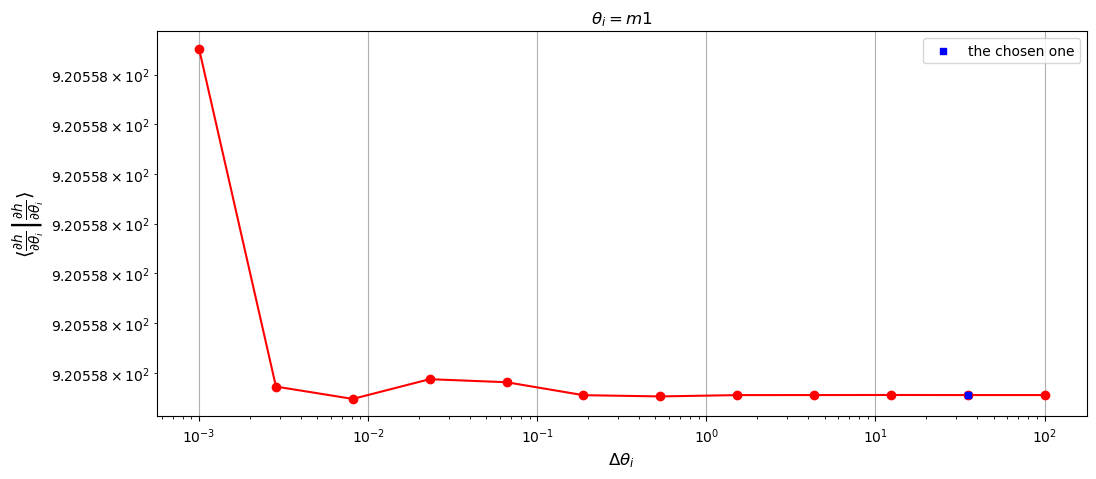

Gamma_ii for m2: 117742508776.2445
Gamma_ii for m2: 117742508767.9001
Gamma_ii for m2: 117742508794.38596
Gamma_ii for m2: 117742508774.20883
Gamma_ii for m2: 117742508748.73755
Gamma_ii for m2: 117742508685.65169
Gamma_ii for m2: 117742508963.54097
Gamma_ii for m2: 117742507848.6258
Gamma_ii for m2: 117742522520.12103
Gamma_ii for m2: 117742511379.02023
Gamma_ii for m2: 117742398048.48196
Gamma_ii for m2: 117742431706.94792
[np.float64(7.086995355584445e-11), np.float64(2.2494726308908007e-10), np.float64(1.7136652032895397e-10), np.float64(2.1633039103438912e-10), np.float64(5.357951169061718e-10), np.float64(2.3601440522437912e-09), np.float64(9.469096563026995e-09), np.float64(1.2460659857827148e-07), np.float64(9.462258507207029e-08), np.float64(9.625295572999766e-07), np.float64(2.8586521842367754e-07)]
0


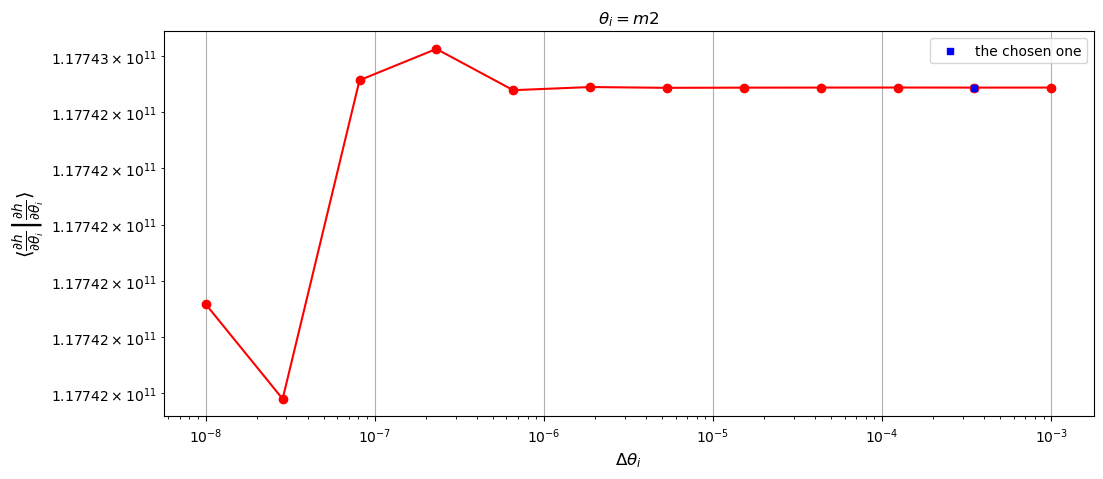

Gamma_ii for a: 9898848788457.709
Gamma_ii for a: 9898846799369.963
Gamma_ii for a: 9898817837782.047
Gamma_ii for a: 9898891369865.906
Gamma_ii for a: 9898873531902.45
Gamma_ii for a: 9899133385340.486
Gamma_ii for a: 9898796108297.904
Gamma_ii for a: 9898173816661.441
Gamma_ii for a: 9905574800011.719
Gamma_ii for a: 9923206389200.904
Gamma_ii for a: 9890791903030.277
Gamma_ii for a: 9964952185444.719
[np.float64(2.0094136078763744e-07), np.float64(2.9257622870353608e-06), np.float64(7.428315061949315e-06), np.float64(1.8020195327824335e-06), np.float64(2.6250119876344265e-05), np.float64(3.4072531537375606e-05), np.float64(6.28693381212802e-05), np.float64(0.0007471533454341881), np.float64(0.0017768036356044573), np.float64(0.003277238717427268), np.float64(0.0074421112148198194)]
0


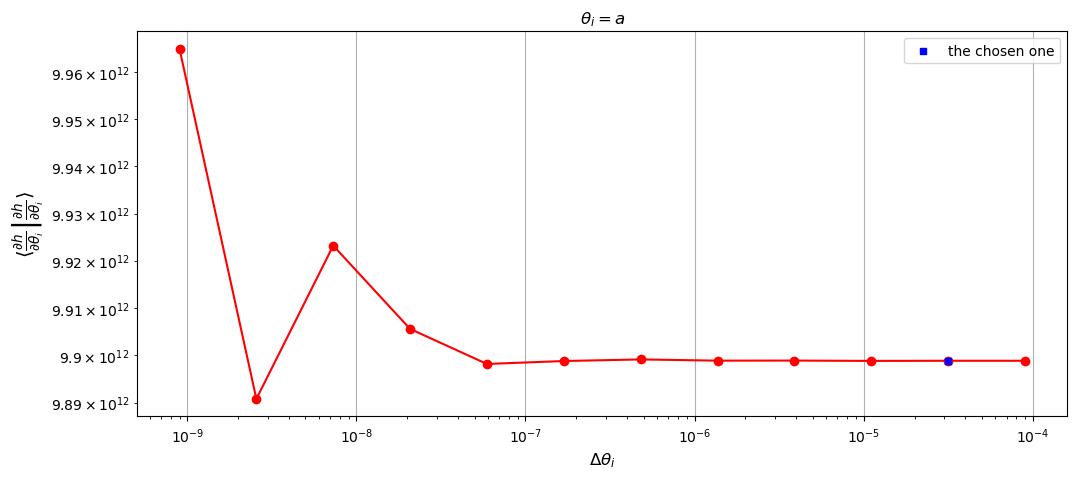

Gamma_ii for p0: 41390401347783.53
Gamma_ii for p0: 41390402909527.7
Gamma_ii for p0: 41390406072709.305
Gamma_ii for p0: 41390405944782.12
Gamma_ii for p0: 41390354603978.58
Gamma_ii for p0: 41390379956946.484
Gamma_ii for p0: 41390412846827.36
Gamma_ii for p0: 41390176002651.03
Gamma_ii for p0: 41392042931926.93
Gamma_ii for p0: 41390159166160.8
Gamma_ii for p0: 41380405764283.75
Gamma_ii for p0: 41334411493658.49
[np.float64(3.773203598159467e-08), np.float64(7.642306277463991e-08), np.float64(3.090744934240664e-09), np.float64(1.24040501779435e-06), np.float64(6.125328622888143e-07), np.float64(7.946255814532438e-07), np.float64(5.7222316791538935e-06), np.float64(4.5103578940734496e-05), np.float64(4.551240691224295e-05), np.float64(0.0002357009724023835), np.float64(0.001112735586723286)]
2


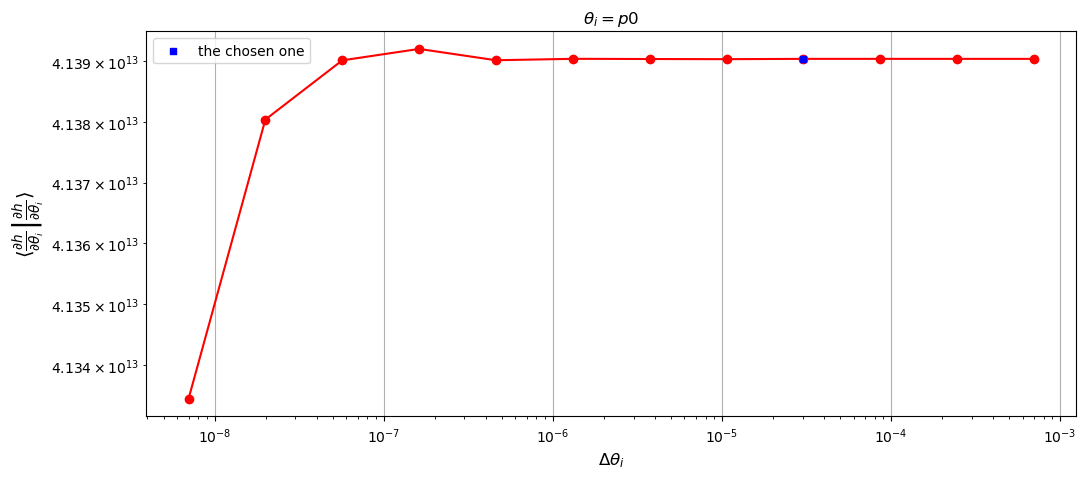

Gamma_ii for e0: 485337642073940.7
Gamma_ii for e0: 485337648940236.5
Gamma_ii for e0: 485337665406317.06
Gamma_ii for e0: 485337293474571.4
Gamma_ii for e0: 485337423603440.2
Gamma_ii for e0: 485338991740628.6
Gamma_ii for e0: 485331634304457.1
Gamma_ii for e0: 485329269421305.44
Gamma_ii for e0: 485365048931355.0
Gamma_ii for e0: 485205517839193.6
Gamma_ii for e0: 483886243493670.3
Gamma_ii for e0: 483607890810046.6
[np.float64(1.4147461725858201e-08), np.float64(3.392706096427702e-08), np.float64(7.663366295732369e-07), np.float64(2.681204096035788e-07), np.float64(3.2310142294842296e-06), np.float64(1.5159605621101035e-05), np.float64(4.872739603171529e-06), np.float64(7.371670071493505e-05), np.float64(0.00032879076246252967), np.float64(0.002726414241492215), np.float64(0.0005755751486135695)]
0


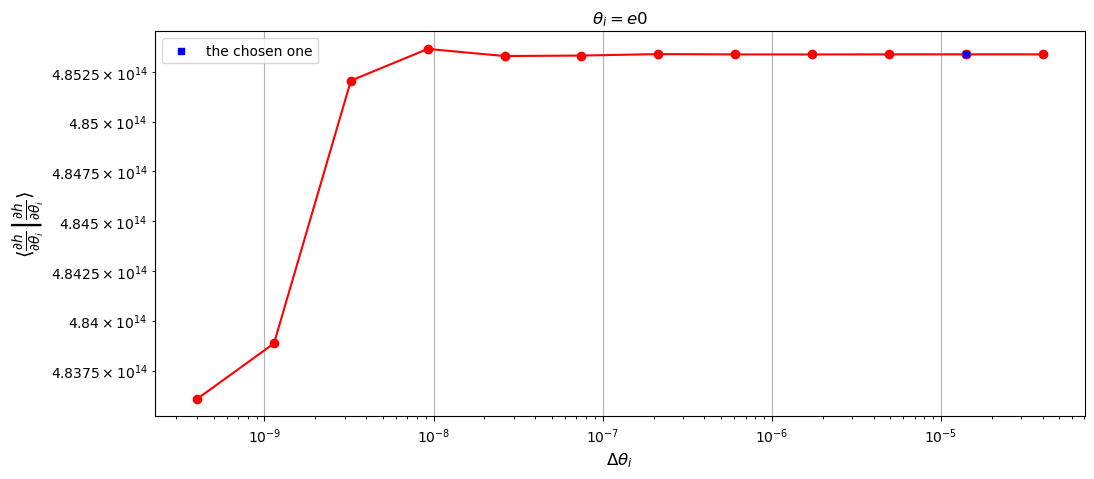

Gamma_ii for qS: 21813.722094537436
Gamma_ii for qS: 21813.724050256784
Gamma_ii for qS: 21813.72405396578
Gamma_ii for qS: 21813.724053972695
Gamma_ii for qS: 21813.724053972197
Gamma_ii for qS: 21813.72405397603
Gamma_ii for qS: 21813.724053972095
Gamma_ii for qS: 21813.724053986385
Gamma_ii for qS: 21813.72405395485
Gamma_ii for qS: 21813.724054353737
Gamma_ii for qS: 21813.72405460684
Gamma_ii for qS: 21813.724054282997
[np.float64(8.965545468911809e-08), np.float64(1.7003038005840398e-10), np.float64(3.170388373470713e-13), np.float64(2.284814345952118e-14), np.float64(1.757806073454824e-13), np.float64(1.804503008992849e-13), np.float64(6.550912956856994e-13), np.float64(1.4456037044327524e-12), np.float64(1.8286019631937093e-11), np.float64(1.1602854282624529e-11), np.float64(1.4845789681074588e-11)]
3


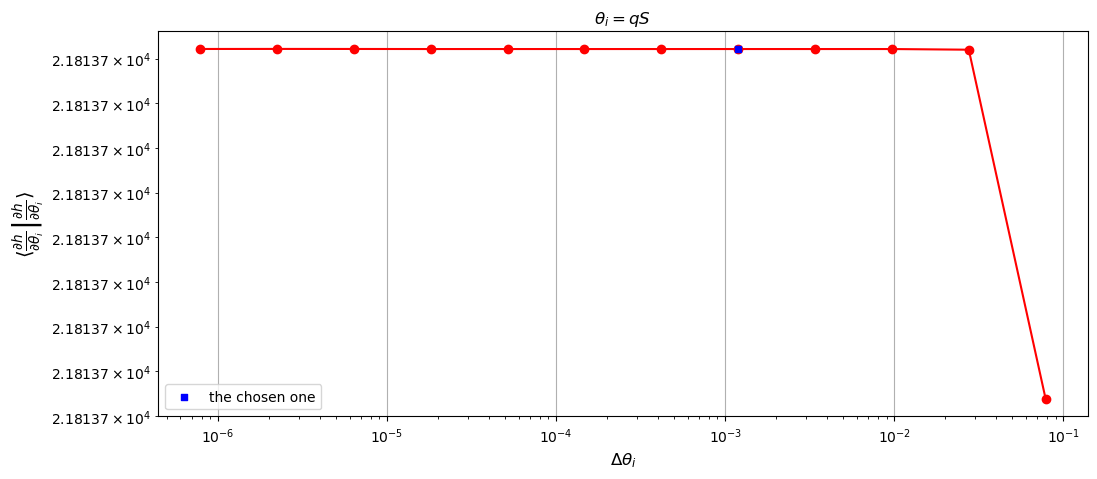

Gamma_ii for phiS: 421389.4065283218
Gamma_ii for phiS: 421389.4061982143
Gamma_ii for phiS: 421389.40619758307
Gamma_ii for phiS: 421389.40619758196
Gamma_ii for phiS: 421389.4061975819
Gamma_ii for phiS: 421389.406197582
Gamma_ii for phiS: 421389.4061975821
Gamma_ii for phiS: 421389.40619758196
Gamma_ii for phiS: 421389.40619758307
Gamma_ii for phiS: 421389.40619758435
Gamma_ii for phiS: 421389.4061975748
Gamma_ii for phiS: 421389.4061975889
[np.float64(7.833787811168256e-10), np.float64(1.4979111141908459e-12), np.float64(2.6245215021787297e-15), np.float64(1.381327106409858e-16), np.float64(2.7626542128197153e-16), np.float64(1.3813271064098574e-16), np.float64(2.7626542128197153e-16), np.float64(2.624521502178723e-15), np.float64(3.03891963410167e-15), np.float64(2.2653764545122052e-14), np.float64(3.342811597511801e-14)]
5


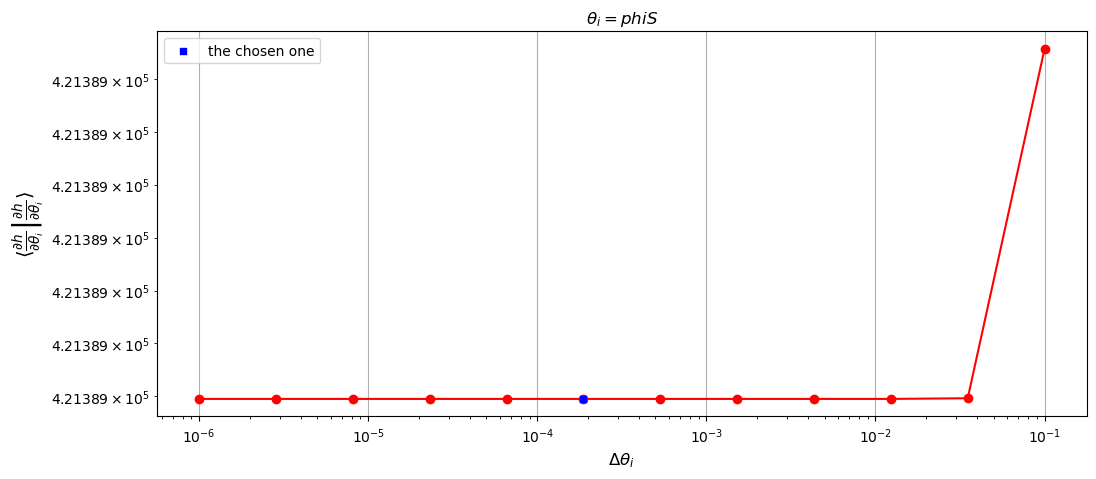

Gamma_ii for dev1p: 3.1447438385152806e-11
Gamma_ii for dev1p: 2.550798682355644e-10
Gamma_ii for dev1p: 2.0690314543963784e-09
Gamma_ii for dev1p: 1.678255202534526e-08
Gamma_ii for dev1p: 1.361284536708947e-07
Gamma_ii for dev1p: 1.1041798572018806e-06
Gamma_ii for dev1p: 8.95634324913398e-06
Gamma_ii for dev1p: 7.264766140507667e-05
Gamma_ii for dev1p: 0.0005892675795042784
Gamma_ii for dev1p: 0.004779731013207306
Gamma_ii for dev1p: 0.03876987187694083
Gamma_ii for dev1p: 0.31447438385152804
[np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557933), np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557936), np.float64(0.8767153260557926), np.float64(0.8767153260557936), np.float64(0.8767153260557937)]
8
minimum relative error is greater than 1% for dev1p. Fisher may be unstable!


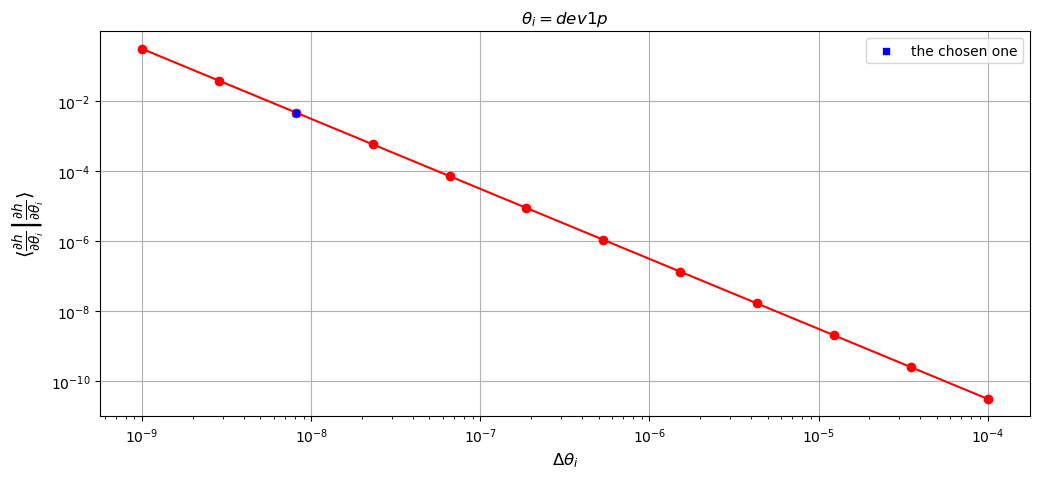

Gamma_ii for dev1e: 3.1447438385152806e-11
Gamma_ii for dev1e: 2.550798682355644e-10
Gamma_ii for dev1e: 2.0690314543963784e-09
Gamma_ii for dev1e: 1.678255202534526e-08
Gamma_ii for dev1e: 1.361284536708947e-07
Gamma_ii for dev1e: 1.1041798572018806e-06
Gamma_ii for dev1e: 8.95634324913398e-06
Gamma_ii for dev1e: 7.264766140507667e-05
Gamma_ii for dev1e: 0.0005892675795042784
Gamma_ii for dev1e: 0.004779731013207306
Gamma_ii for dev1e: 0.03876987187694083
Gamma_ii for dev1e: 0.31447438385152804
[np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557933), np.float64(0.8767153260557932), np.float64(0.8767153260557937), np.float64(0.8767153260557936), np.float64(0.8767153260557926), np.float64(0.8767153260557936), np.float64(0.8767153260557937)]
8
minimum relative error is greater than 1% for dev1e. Fisher may be unstable!


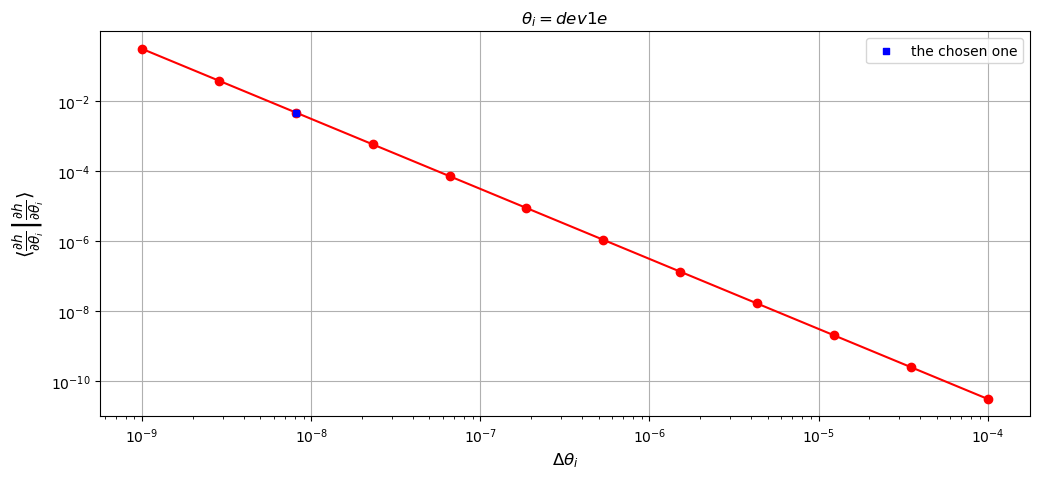

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 3.160072560793623e-05, 'p0': 3.0301328967581437e-05, 'e0': 1.4044766936860542e-05, 'qS': 0.0011937353730786609, 'phiS': 0.0001873817422860385, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev1p': 8.11130830789689e-09, 'dev1e': 8.11130830789689e-09}
Time taken to compute stable deltas is 489.9031341075897 seconds
calculating Fisher matrix...
Finished derivatives


LinAlgError: Singular matrix

In [8]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

Fisher = sef(*pars_list,param_names = param_names,T = T, dt = dt, add_param_args=add_param_args,\
             der_order = der_order, Ndelta = Ndelta, stability_plot = stability_plot,
            live_dangerously = False)

In [ ]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1    
    return J.T@Fisher@J

In [ ]:
fisher_=Fisher.copy()
fisher_
sef.deltas["Phi_phi0"] = 1e-5
sef.deltas["Phi_r0"] = 1e-5
sef.deltas

In [ ]:


#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)



In [ ]:
sef.param_names

In [ ]:
sef.deltas

In [ ]:


print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_list}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
    if sef.param_names[k] in list(sef.minmax.keys()):
        if sef.wave_params[sef.param_names[k]] <= sef.minmax[sef.param_names[k]][0]:
            dtv.append(derivative(waveform_generator=sef.waveform_generator, parameters= sef.wave_params,param_to_vary = sef.param_names[k], delta= sef.deltas[sef.param_names[k]], kind="forward", waveform=sef.waveform, order=sef.order, use_gpu=sef.use_gpu, waveform_kwargs=sef.waveform_kwargs))
        elif sef.wave_params[sef.param_names[k]] > sef.minmax[sef.param_names[k]][1]:
            dtv.append(derivative(waveform_generator=sef.waveform_generator, parameters= sef.wave_params,param_to_vary = sef.param_names[k], delta= sef.deltas[sef.param_names[k]], kind="backward", waveform=sef.waveform, order=sef.order, use_gpu=sef.use_gpu, waveform_kwargs=sef.waveform_kwargs))
        else:
            dtv.append(derivative(waveform_generator=sef.waveform_generator,parameters=sef.wave_params,param_to_vary=sef.param_names[k], delta = sef.deltas[sef.param_names[k]],use_gpu=sef.use_gpu, waveform=sef.waveform, order=sef.order, waveform_kwargs=sef.waveform_kwargs))
    else:
        dtv.append(derivative(waveform_generator = sef.waveform_generator,parameters=sef.wave_params,param_to_vary = sef.param_names[k],delta= sef.deltas[sef.param_names[k]],use_gpu=sef.use_gpu, waveform=sef.waveform, order=sef.order, waveform_kwargs=sef.waveform_kwargs))
    print("Finished derivatives")
    if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h
    #elif sef.param_names[k] == 'm2':
     #   dtv[k] *= m2 #to obtain \partial_{log m2}h



In [ ]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_1_p,dev_1_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])

waveform_approx = sef.waveform
waveform_approx

In [ ]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=False)

waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= np.array(waveform_true)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000], label="Approximation")
axs[0].plot(waveform_true[0][0:2000], label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot((waveform_true[0] - waveform_approx[0])[0:])
axs[1].set_title("Difference of waveforms")

plt.tight_layout()



In [ ]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)



In [ ]:
print(sigma_contour)

In [ ]:
biased_params

In [ ]:
params_truth_in_considered